# 1 Import Libraries

!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
import kagglehub

path = kagglehub.dataset_download("jtiptj/chest-xray-pneumoniacovid19tuberculosis")

print("Path to dataset files:", path)

In [2]:
# ==============================
# 1️⃣ Import Required Libraries
# ==============================

import matplotlib.pyplot as plt        # For plotting graphs (accuracy/loss)
import seaborn as sns                  # For advanced visualizations (heatmap)
import pandas as pd                    # For handling dataset

import tensorflow as tf                # Main deep learning framework
from tensorflow import keras           # High-level API


# 2 Image Data Preprocessing

### 2.1 traing Image

In [3]:
train_data = keras.utils.image_dataset_from_directory(
    'train',
    label_mode='categorical',   # 38 classes → one-hot encoding
    image_size=(224, 224),
    batch_size=32,
    shuffle=True
)

Found 13028 files belonging to 4 classes.




training_data = keras.utils.image_dataset_from_directory(
    directory='train',          # Path to training folder
    labels='inferred',          # Automatically infer labels from folder names
    label_mode='categorical',   # Multi-class classification (one-hot encoding)
    batch_size=32,              # Number of images per batch
    image_size=(128, 128),      # Resize all images to 128x128
    shuffle=True,               # Shuffle data to avoid memorization
    seed=42,                    # For reproducibility
    validation_split=None,      # No validation split here
    interpolation="bilinear",   # Resize method
    follow_links=False,         # Ignore symbolic links
    crop_to_aspect_ratio=False  # Do not crop image
)

| Parameter            | Default Value | Need to Write?                      |
| -------------------- | ------------- | ----------------------------------- |
| labels               | "inferred"    | ❌ Already default                   |
| seed                 | None          | ❌ Only needed with validation_split |
| validation_split     | None          | ❌ Not using split                   |
| interpolation        | "bilinear"    | ❌ Default                           |
| follow_links         | False         | ❌ Default                           |
| crop_to_aspect_ratio | False         | ❌ Default                           |


### 2.2 Valid image

In [4]:
valid_data = tf.keras.utils.image_dataset_from_directory(
    'valid',                    # Path to validation folder
    label_mode='categorical',   # Multi-class (38 classes → one-hot)
    image_size=(224, 224),      # Resize images
    batch_size=32,              # 32 images per batch
    shuffle=False               # No need to shuffle validation data
)

Found 761 files belonging to 4 classes.


Chek data

In [5]:
train_data

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 4), dtype=tf.float32, name=None))>

In [6]:
for x, y in train_data:
    print('img shape ' , x.shape)   # Image batch shape
    print('label shape', y.shape)   # Label batch shape
    break

img shape  (32, 224, 224, 3)
label shape (32, 4)


batch_size = 32

image_size = (128,128)

color_mode = 'rgb'

38 classes

img shape  (32, 128, 128, 3)

| Value | Meaning      |
| ----- | ------------ |
| 32    | Batch size   |
| 128   | Height       |
| 128   | Width        |
| 3     | RGB channels |


label shape (32, 38)
| Value | Meaning                             |
| ----- | ----------------------------------- |
| 32    | Batch size                          |
| 38    | Number of classes (one-hot encoded) |


In [7]:
valid_data

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 4), dtype=tf.float32, name=None))>

In [8]:
for x, y in valid_data:
    print('img shape ' , x.shape)   # Image batch shape
    print('label shape', y.shape)   # Label batch shape
    break

img shape  (32, 224, 224, 3)
label shape (32, 4)


# 3 Build CNN Arch

In [9]:
# models
from keras.models import Sequential   # model
from keras.layers import (Dense, Conv2D, Dropout, 
                          BatchNormalization, 
                          Flatten, MaxPool2D,Concatenate,GlobalAveragePooling2D) # Layer
from tensorflow.keras.models import Model
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras import layers, models

In [10]:
# create model
model = Sequential()

In [11]:
# Create Layer 1 (First Convolution Layer)

model.add(Conv2D(
    32,                 # Number of filters
    kernel_size=3,      # Size of convolution filter
    padding='same',     # Output size same as input
    activation='relu',  # Activation function
    input_shape=(224,224,3)  # Input image shape
))

f:\Deva\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
# create Layer 2
model.add(Conv2D(
    64,                 # Number of filters
    kernel_size=3,      # Size of convolution filter
    padding='same',     # Output size same as input
    activation='relu',  # Activation function
))

In [13]:
# add pooling
model.add(MaxPool2D(pool_size=2,strides=2))

MaxPooling is used to:

✔ Reduce image size

✔ Reduce computation

✔ Keep important features

✔ Prevent overfitting

In [14]:
# Create  Layer 3
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))
model.add(Dropout(0.15)) # Randomly drops 15% neurons → prevents overfitting
model.add(BatchNormalization()) # Normalizes output → faster & stable training


In [15]:
# Create  Layer 4
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))
model.add(Dropout(0.2)) # Randomly drops 15% neurons → prevents overfitting
model.add(BatchNormalization()) # Normalizes output → faster & stable training


In [16]:
# flatten
model.add(Flatten())
# Converts 2D feature maps into 1D vector
# Required before connecting to Dense (Fully Connected) layers

(batch_size, height, width, channels)

Example:  
(32, 16, 16, 64)

After flat  
(32, 16384)

fun
16 × 16 × 64 = 16384

In [17]:
# add dense
model.add(Dense(1500,activation='relu'))

In [18]:
model.add(Dropout(0.4))

In [19]:
#Output Layer
model.add(Dense(units=4,activation='softmax'))

# 4 Model Compilling

In [20]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [21]:
# summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 56, 56, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1500)           │    75,265,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         6,004 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,365,264 (287.50 MB)

 Trainable params: 75,365,008 (287.49 MB)

 Non-trainable params: 256 (1.00 KB)

# 5 Model Training

5.1 Early Stoping

In [22]:
# Import EarlyStopping class from Keras callbacks module
from keras.callbacks import EarlyStopping


# Create EarlyStopping object and store in variable 'callback'
callback = EarlyStopping(

    monitor='val_loss',        # Metric to monitor (validation loss)

    min_delta=0.01,            # Minimum change required to count as improvement

    patience=5,                # Number of epochs to wait before stopping if no improvement

    verbose=1,                 # Print message when early stopping happens (1 = show message)

    mode='auto',               # Automatically decide min/max based on monitored metric

    baseline=None,             # Training will stop if model doesn't reach this baseline value (None = ignore)

    restore_best_weights=True, # After stopping, restore weights from best epoch

    start_from_epoch=0         # Start monitoring from this epoch number
)

5.2 Model training

In [23]:
training_history = model.fit(
    train_data,                 # Training dataset
    validation_data=valid_data, # Validation dataset
    epochs=20,                  # Number of training cycles
    verbose=1 ,                  # Show training progress
    callbacks=[callback]        # Custom callbacks (like EarlyStopping)
)

Epoch 1/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 332s 808ms/step - accuracy: 0.8789 - loss: 0.5641 - val_accuracy: 0.8200 - val_loss: 0.7476
Epoch 2/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 331s 811ms/step - accuracy: 0.9354 - loss: 0.2095 - val_accuracy: 0.2576 - val_loss: 9.7834
Epoch 3/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 332s 813ms/step - accuracy: 0.9460 - loss: 0.1673 - val_accuracy: 0.7017 - val_loss: 1.8772
Epoch 4/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 332s 813ms/step - accuracy: 0.9559 - loss: 0.1522 - val_accuracy: 0.8528 - val_loss: 0.5224
Epoch 5/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 333s 815ms/step - accuracy: 0.9649 - loss: 0.1193 - val_accuracy: 0.8489 - val_loss: 0.6608
Epoch 6/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 332s 814ms/step - accuracy: 0.9628 - loss: 0.1149 - val_accuracy: 0.9054 - val_loss: 0.4357
Epoch 7/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 333s 815ms/step - accuracy: 0.9732 - loss: 0.0811 - val_accuracy: 0.9133 - val_loss: 0.3136
Epoch 8/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 333s 816ms/step - accuracy: 0.9749 -

In [24]:
training_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [25]:
training_history.history['loss']

[0.5641128420829773,
 0.2094941884279251,
 0.16725729405879974,
 0.15219874680042267,
 0.1193125993013382,
 0.1149001494050026,
 0.08110400289297104,
 0.07598298043012619,
 0.12929053604602814,
 0.12132438272237778,
 0.08553121238946915,
 0.0647168904542923]

In [26]:
#Model Evaluation on Training set
train_loss,train_acc = model.evaluate(train_data)

val_loss,val_acc = model.evaluate(valid_data)

408/408 ━━━━━━━━━━━━━━━━━━━━ 47s 115ms/step - accuracy: 0.9278 - loss: 0.2207
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step - accuracy: 0.9133 - loss: 0.3136


In [27]:
#Model on Validation set
# val_loss,val_acc = model.evaluate(valid_data)

In [28]:
print('Train')
print(f'train_loss - {train_loss}\ntrain_acc - {train_acc}\n')
print('Test')
print(f'test_loss - {val_loss}\ntest_acc - {val_acc}')

Train
train_loss - 0.2206648886203766
train_acc - 0.927847683429718

Test
test_loss - 0.3135858476161957
test_acc - 0.9132720232009888


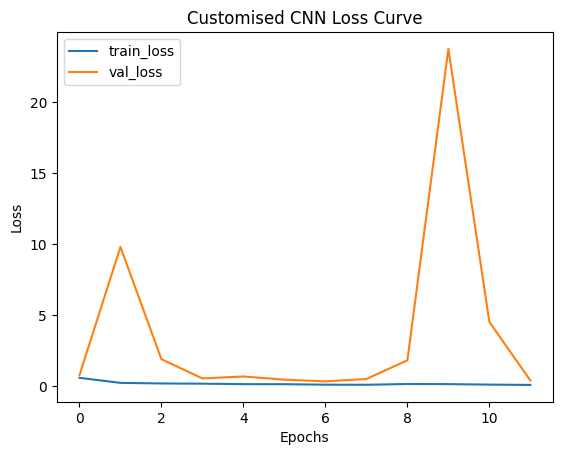

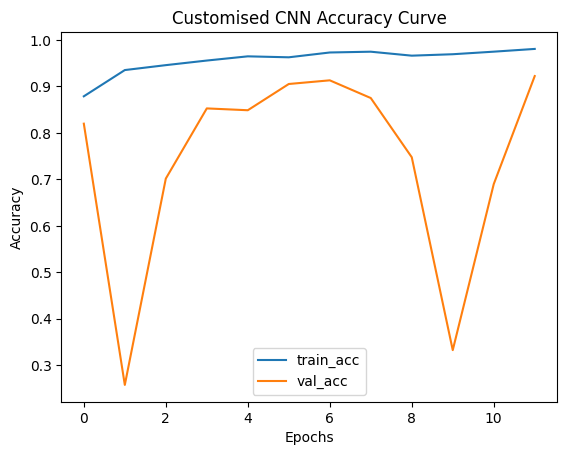

In [36]:

# Loss curve
plt.plot(training_history.history['loss'], label='train_loss')
plt.plot(training_history.history['val_loss'], label='val_loss')
plt.legend()
plt.title('Customised CNN Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

# Accuracy curve
plt.plot(training_history.history['accuracy'], label='train_acc')
plt.plot(training_history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title('Customised CNN Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

RESNET

In [30]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

In [31]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.applications import ResNet50

# Input layer
input_layer = Input(shape=(224,224,3))

# Base ResNet model
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_tensor=input_layer
)

# Freeze base model layers
for layer in base_model.layers:
    layer.trainable = False

# Custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

# Output layer (change class count if needed)
output_layer = Dense(4, activation='softmax')(x)

# Build model
model = Model(inputs=input_layer, outputs=output_layer)

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary
model.summary()

Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,284 (91.98 MB)

 Trainable params: 525,572 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [32]:
history = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=20,
    callbacks=[callback]
)

Epoch 1/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 196s 468ms/step - accuracy: 0.8891 - loss: 0.2858 - val_accuracy: 0.9593 - val_loss: 0.1143
Epoch 2/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 188s 460ms/step - accuracy: 0.9308 - loss: 0.1714 - val_accuracy: 0.9671 - val_loss: 0.0918
Epoch 3/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 187s 457ms/step - accuracy: 0.9427 - loss: 0.1448 - val_accuracy: 0.9724 - val_loss: 0.0919
Epoch 4/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 187s 458ms/step - accuracy: 0.9462 - loss: 0.1371 - val_accuracy: 0.9645 - val_loss: 0.0794
Epoch 5/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 187s 457ms/step - accuracy: 0.9526 - loss: 0.1227 - val_accuracy: 0.9593 - val_loss: 0.0880
Epoch 6/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 187s 457ms/step - accuracy: 0.9546 - loss: 0.1141 - val_accuracy: 0.9750 - val_loss: 0.0836
Epoch 7/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 187s 458ms/step - accuracy: 0.9542 - loss: 0.1198 - val_accuracy: 0.9658 - val_loss: 0.0842
Epoch 8/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 187s 458ms/step - accuracy: 0.9560 -

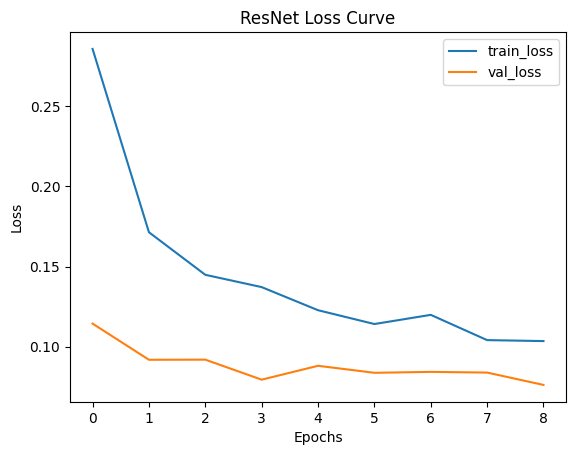

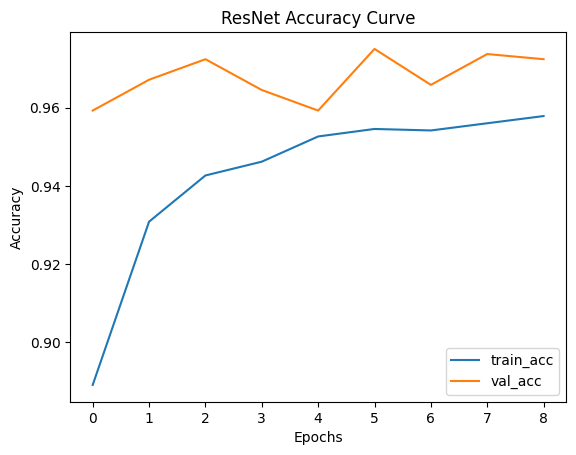

In [38]:

# Loss curve
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title('ResNet Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

# Accuracy curve
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title('ResNet Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

fusion

In [33]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.layers import Concatenate, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.applications import ResNet50

# Input layer
input_layer = Input(shape=(224,224,3))

# -------------------------
# Custom CNN Branch
# -------------------------

x = Conv2D(32,(3,3),activation='relu',padding='same')(input_layer)
x = MaxPooling2D(2,2)(x)

x = Conv2D(64,(3,3),activation='relu',padding='same')(x)
x = MaxPooling2D(2,2)(x)

x = Conv2D(128,(3,3),activation='relu',padding='same')(x)
x = MaxPooling2D(2,2)(x)

cnn_branch = GlobalAveragePooling2D()(x)

# -------------------------
# ResNet Branch
# -------------------------

resnet = ResNet50(
    weights='imagenet',
    include_top=False,
    input_tensor=input_layer
)

for layer in resnet.layers:
    layer.trainable = False

resnet_branch = GlobalAveragePooling2D()(resnet.output)

# -------------------------
# Fusion Layer
# -------------------------

fusion = Concatenate()([cnn_branch, resnet_branch])

x = Dense(256,activation='relu')(fusion)
x = Dropout(0.5)(x)

output = Dense(4,activation='softmax')(x)   # change class number if needed

# Final model
fusion_model = Model(inputs=input_layer, outputs=output)

# Compile
fusion_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

fusion_model.summary()

Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,239,300 (92.47 MB)

 Trainable params: 651,588 (2.49 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [34]:
fusion_history = fusion_model.fit(
    train_data,
    validation_data=valid_data,
    epochs=20,
    callbacks=[callback]
)

Epoch 1/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 269s 646ms/step - accuracy: 0.8743 - loss: 0.4718 - val_accuracy: 0.9619 - val_loss: 0.1119
Epoch 2/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 261s 640ms/step - accuracy: 0.9363 - loss: 0.1676 - val_accuracy: 0.9632 - val_loss: 0.0910
Epoch 3/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 262s 641ms/step - accuracy: 0.9460 - loss: 0.1393 - val_accuracy: 0.9698 - val_loss: 0.0849
Epoch 4/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 263s 644ms/step - accuracy: 0.9474 - loss: 0.1341 - val_accuracy: 0.9566 - val_loss: 0.1061
Epoch 5/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 264s 646ms/step - accuracy: 0.9569 - loss: 0.1144 - val_accuracy: 0.9790 - val_loss: 0.0715
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.


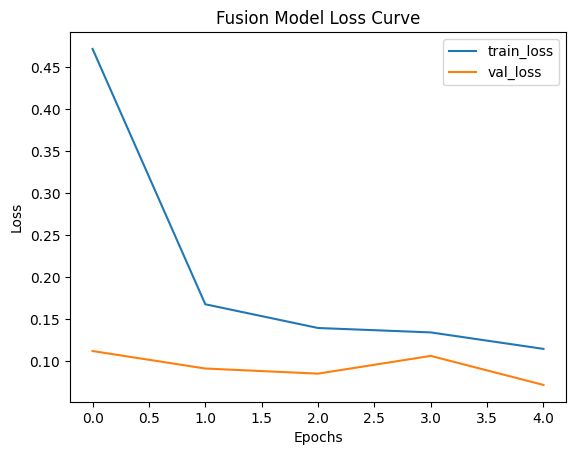

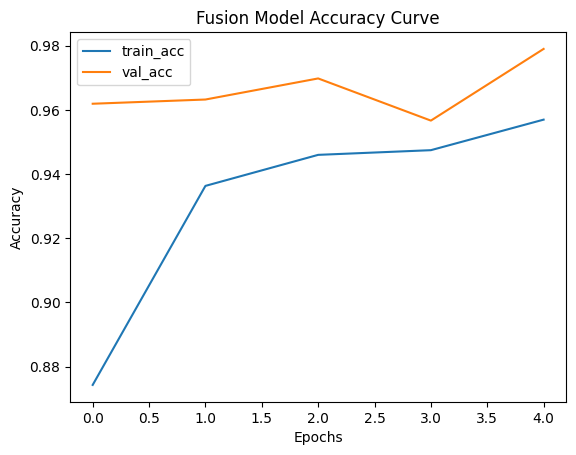

In [37]:

# Loss curve
plt.plot(fusion_history.history['loss'], label='train_loss')
plt.plot(fusion_history.history['val_loss'], label='val_loss')
plt.legend()
plt.title('Fusion Model Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

# Accuracy curve
plt.plot(fusion_history.history['accuracy'], label='train_acc')
plt.plot(fusion_history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title('Fusion Model Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

In [40]:
y_pred = fusion_model.predict(valid_data)
y_pred,y_pred.shape

24/24 ━━━━━━━━━━━━━━━━━━━━ 14s 518ms/step


(array([[7.7001911e-01, 1.7514642e-02, 2.1212524e-01, 3.4104375e-04],
        [8.5665828e-01, 3.2448696e-03, 1.3976197e-01, 3.3483148e-04],
        [9.0045506e-01, 1.2420769e-03, 9.8192438e-02, 1.1042331e-04],
        ...,
        [1.0192195e-05, 2.9431089e-07, 6.5870393e-07, 9.9998891e-01],
        [4.6817959e-07, 6.2782753e-08, 9.5558926e-07, 9.9999845e-01],
        [1.2347964e-07, 3.5712794e-08, 9.4313300e-08, 9.9999976e-01]],
       shape=(761, 4), dtype=float32),
 (761, 4))

In [41]:
predicted_categories = tf.argmax(y_pred,axis=1)
predicted_categories

<tf.Tensor: shape=(761,), dtype=int64, numpy=
array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
     

In [43]:
from sklearn.metrics import classification_report,confusion_matrix

In [48]:
true_categories = tf.concat([y for x,y in valid_data],axis=0)
true_categories

<tf.Tensor: shape=(761, 4), dtype=float32, numpy=
array([[1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       ...,
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.]], shape=(761, 4), dtype=float32)>

In [49]:
Y_true = tf.argmax(true_categories,axis=1)
Y_true

<tf.Tensor: shape=(761,), dtype=int64, numpy=
array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
     

In [51]:
report = classification_report(Y_true, predicted_categories, target_names=valid_data.class_names)
print(report)

              precision    recall  f1-score   support

      NORMAL       0.94      0.96      0.95       274
   PNEUMONIA       0.95      0.98      0.97       213
TUBERCULOSIS       0.98      0.94      0.96       207
     UNKNOWN       1.00      1.00      1.00        67

    accuracy                           0.96       761
   macro avg       0.97      0.97      0.97       761
weighted avg       0.96      0.96      0.96       761



In [52]:
model.save("train.keras")

In [53]:
#Recording History in json
import json
with open("training_hist.json","w") as f:
    json.dump(training_history.history,f)